In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
"""
Model Performance Evaluation Script

Calculate AUPRC and AUROC metrics for the ensemble model predictions.
This script evaluates the performance of the chemprop ensemble model.
"""

import csv
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


print("✅ Libraries imported successfully!")

/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Libraries imported successfully!


In [3]:
# Load the prediction results
predictions_df = pd.read_csv('chemprop/test_20_results_rdkit.csv')

# Load the true labels
true_labels_df = pd.read_csv('activity_20.csv')

# Extract predictions and true labels
y_scores = predictions_df['ACTIVITY'].values
y_true = true_labels_df['ACTIVITY'].values
y_scores

array([0.83715487, 0.67383826, 0.73256018, 0.70080786, 0.18468722,
       0.93886664, 0.9206512 , 0.59809495, 0.14378423, 0.67920154,
       0.35771231, 0.76757898, 0.04064796, 0.72820529, 0.36896891,
       0.90798997, 0.94624365, 0.80191211, 0.23303636, 0.56426892,
       0.53150898, 0.45886661, 0.94488135, 0.42471939, 0.56386577,
       0.08208032, 0.58790492, 0.257811  , 0.06164694, 0.79491636,
       0.59792509, 0.85780357, 0.90093874, 0.90798998, 0.87144387,
       0.61795844, 0.94188284, 0.80943777, 0.38678189, 0.50418963,
       0.5961812 , 0.10384679, 0.84678893, 0.03411971, 0.17309533,
       0.77797166, 0.75685257, 0.56386578, 0.80283847, 0.9232106 ,
       0.03714191, 0.93335075])

In [4]:
y_true

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1])

In [5]:

def calculate_auprc(y_true, y_scores):
    """Calculate Area Under Precision-Recall Curve"""
    try:
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        auprc = auc(recall, precision)
        return auprc, precision, recall
    except Exception as e:
        print(f"❌ Error calculating AUPRC: {e}")
        return None, None, None

def calculate_auroc(y_true, y_scores):
    """Calculate Area Under ROC Curve"""
    try:
        auroc = roc_auc_score(y_true, y_scores)
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        return auroc, fpr, tpr
    except Exception as e:
        print(f"❌ Error calculating AUROC: {e}")
        return None, None, None

def calculate_metrics_pandas(y_true, y_scores):
    """Calculate metrics using pandas for easier data handling"""
    
    try:
        # Load predictions
        
        
        # Calculate metrics
        auprc, precision, recall = calculate_auprc(y_true, y_scores)
        auroc, fpr, tpr = calculate_auroc(y_true, y_scores)
        
        print(f"\n📊 Performance Metrics:")
        print(f"AUPRC: {auprc:.4f}")
        print(f"AUROC: {auroc:.4f}")
        
        return auprc, auroc, precision, recall, fpr, tpr, y_scores, y_true
        
    except Exception as e:
        print(f"❌ Error in pandas calculation: {e}")
        return None, None, None, None, None, None, None, None

def plot_performance_curves(auprc, auroc, precision, recall, fpr, tpr):
    """Plot performance curves"""
    if auprc is not None and auroc is not None:
        
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Precision-Recall Curve
        ax1.plot(recall, precision, 'b-', linewidth=2, label=f'AUPRC = {auprc:.4f}')
        ax1.set_xlabel('Recall')
        ax1.set_ylabel('Precision')
        ax1.set_title('Precision-Recall Curve')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # ROC Curve
        ax2.plot(fpr, tpr, 'r-', linewidth=2, label=f'AUROC = {auroc:.4f}')
        ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('performance_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✅ Performance curves plotted and saved as 'performance_curves.png'!")
    else:
        print("❌ Cannot plot curves - metrics not calculated")


In [6]:
metrics = calculate_metrics_pandas(y_true, y_scores)
auprc, auroc, precision, recall, fpr, tpr, y_scores, y_true = metrics


📊 Performance Metrics:
AUPRC: 0.8713
AUROC: 0.8681



📊 Data Summary:
Number of predictions: 52
Number of true labels: 52
Prediction range: 0.034 to 0.946
True labels: {0, 1}
Class distribution: {0: 27, 1: 25}

📋 Additional Statistics:
Mean prediction score: 0.5919
Std prediction score: 0.2916


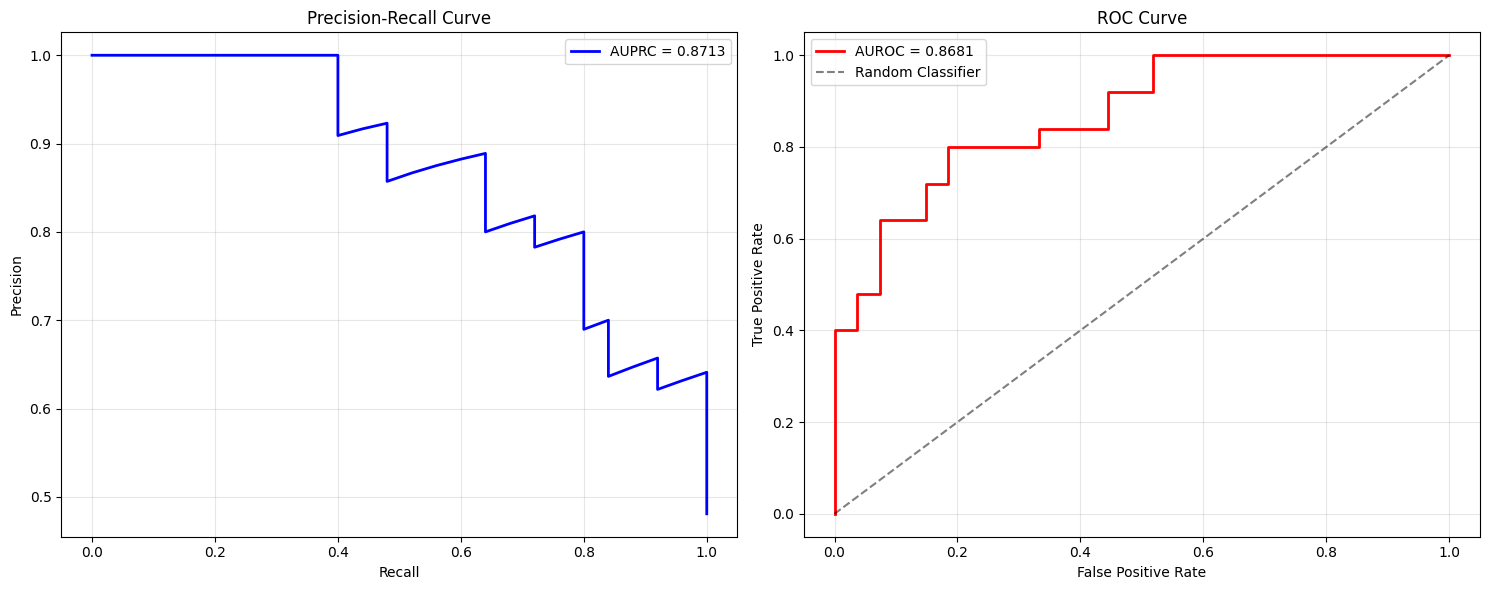

✅ Performance curves plotted and saved as 'performance_curves.png'!

💡 Performance Summary:
📈 AUPRC: 0.8713
   • AUPRC (0.8713) indicates EXCELLENT performance
📊 AUROC: 0.8681
   • AUROC (0.8681) indicates GOOD performance

✅ Results saved to 'performance_results.txt'


In [7]:
auprc, auroc, precision, recall, fpr, tpr, y_scores, y_true = metrics

if y_scores is not None and y_true is not None:
        print(f"\n📊 Data Summary:")
        print(f"Number of predictions: {len(y_scores)}")
        print(f"Number of true labels: {len(y_true)}")
        print(f"Prediction range: {min(y_scores):.3f} to {max(y_scores):.3f}")
        print(f"True labels: {set(y_true)}")
        print(f"Class distribution: {dict(pd.Series(y_true).value_counts())}")
        
        # Additional statistics
        print(f"\n📋 Additional Statistics:")
        print(f"Mean prediction score: {np.mean(y_scores):.4f}")
        print(f"Std prediction score: {np.std(y_scores):.4f}")
        
        # Plot curves
        plot_performance_curves(auprc, auroc, precision, recall, fpr, tpr)
        
        # Summary and interpretation
        print(f"\n💡 Performance Summary:")
        if auprc is not None:
            print(f"📈 AUPRC: {auprc:.4f}")
            if auprc > 0.8:
                print(f"   • AUPRC ({auprc:.4f}) indicates EXCELLENT performance")
            elif auprc > 0.6:
                print(f"   • AUPRC ({auprc:.4f}) indicates GOOD performance")
            elif auprc > 0.4:
                print(f"   • AUPRC ({auprc:.4f}) indicates FAIR performance")
            else:
                print(f"   • AUPRC ({auprc:.4f}) indicates POOR performance")
        
        if auroc is not None:
            print(f"📊 AUROC: {auroc:.4f}")
            if auroc > 0.9:
                print(f"   • AUROC ({auroc:.4f}) indicates EXCELLENT performance")
            elif auroc > 0.8:
                print(f"   • AUROC ({auroc:.4f}) indicates GOOD performance")
            elif auroc > 0.7:
                print(f"   • AUROC ({auroc:.4f}) indicates FAIR performance")
            else:
                print(f"   • AUROC ({auroc:.4f}) indicates POOR performance")
        
        # Save results to file
        results = {
            'AUPRC': auprc,
            'AUROC': auroc,
            'Num_Samples': len(y_scores),
            'Class_Distribution': dict(pd.Series(y_true).value_counts()),
            'Mean_Prediction': np.mean(y_scores),
            'Std_Prediction': np.std(y_scores)
        }
        
        with open('performance_results.txt', 'w') as f:
            f.write("Model Performance Results\n")
            f.write("=" * 30 + "\n\n")
            for key, value in results.items():
                f.write(f"{key}: {value}\n")
        
        print(f"\n✅ Results saved to 'performance_results.txt'")
        
else:
        print("❌ Failed to load data or calculate metrics")
    
    
    
    
    
    

code from chatgpt

In [8]:
metrics = calculate_metrics_pandas(y_true, y_scores)
auprc, auroc, precision, recall, fpr, tpr, y_scores, y_true = metrics


📊 Performance Metrics:
AUPRC: 0.8713
AUROC: 0.8681


Optimal threshold: 0.62
Best F1-score   : 0.7843


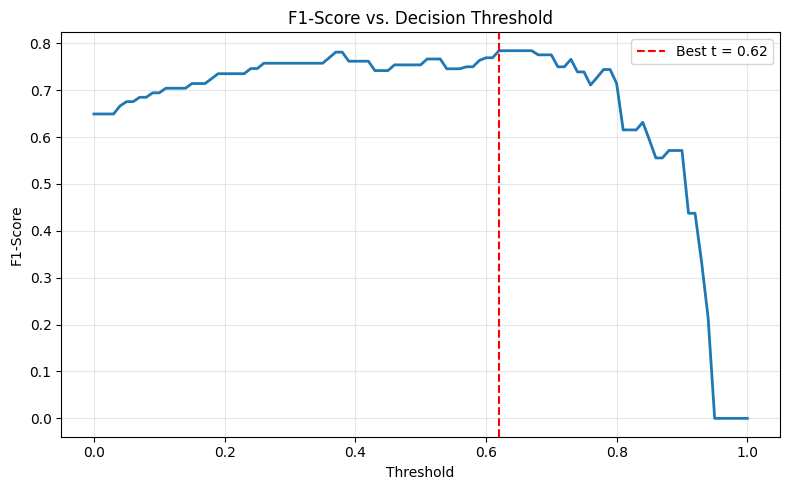

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# --------------------------------------------
# 1. INSERT YOUR DATA HERE
# y_true: array-like of 0s and 1s (ground-truth)
# y_scores: predicted probabilities or scores in [0, 1]
# --------------------------------------------

# --------------------------------------------
# 2. Sweep thresholds and compute F1
# --------------------------------------------
thresholds = np.linspace(0, 1, 101)       # 0.00, 0.01, ..., 1.00
f1_values  = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    f1_values.append(f1)

f1_values = np.array(f1_values)
best_idx  = np.argmax(f1_values)
best_t    = thresholds[best_idx]
best_f1   = f1_values[best_idx]

print(f"Optimal threshold: {best_t:.2f}")
print(f"Best F1-score   : {best_f1:.4f}")

# --------------------------------------------
# 3. Plot F1 vs. threshold
# --------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_values, lw=2)
plt.axvline(best_t, color='red', ls='--', label=f'Best t = {best_t:.2f}')
plt.title('F1-Score vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()